# Bank Customer Churn Prediction & Retention Analytics System

## 06 — Model Explainability & Churn Drivers

### Objective

This notebook explains the predictions produced by the final optimized
XGBoost churn model.

The analysis focuses on:

- Global feature importance
- Identification of major churn drivers
- Feature impact on model predictions
- Individual customer risk explanations
- Business interpretation of model behavior

### Business Question

The objective is not only to predict which customers may churn, but also
to understand the factors associated with higher predicted churn risk so
that retention strategies can be better targeted.

### Final Model

The final model is an optimized XGBoost classifier using a classification
threshold of 0.35.

In [1]:
import pandas as pd
import numpy as np
import joblib
import json

import matplotlib.pyplot as plt

from pathlib import Path

import shap

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

D:\Anaconda\envs\churn-project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.


In [2]:
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_PATH = PROJECT_ROOT / "models"
REPORTS_PATH = PROJECT_ROOT / "reports"

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\balle\customer-churn-prediction-retention-analytics


In [4]:
df = pd.read_csv(
    DATA_PROCESSED / "churn_modeling_dataset.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (10000, 15)


In [5]:
final_model = joblib.load(
    MODELS_PATH / "final_churn_model.joblib"
)

preprocessor = joblib.load(
    MODELS_PATH / "final_preprocessor.joblib"
)

print("Final model loaded.")
print("Preprocessor loaded.")

Final model loaded.
Preprocessor loaded.


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(
    columns=["Exited"]
)

y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (8000, 14)
Test: (2000, 14)


In [7]:
X_test_processed = preprocessor.transform(
    X_test
)

print(
    "Processed test shape:",
    X_test_processed.shape
)

Processed test shape: (2000, 31)


In [8]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFeature names:")
for i, feature in enumerate(feature_names):
    print(i, feature)

Number of features: 31

Feature names:
0 num__CreditScore
1 num__Age
2 num__Tenure
3 num__Balance
4 num__EstimatedSalary
5 cat__Geography_Germany
6 cat__Geography_Spain
7 cat__Gender_Male
8 cat__NumOfProducts_2
9 cat__NumOfProducts_3
10 cat__NumOfProducts_4
11 cat__AgeGroup_26-35
12 cat__AgeGroup_36-45
13 cat__AgeGroup_46-55
14 cat__AgeGroup_56-65
15 cat__AgeGroup_66+
16 cat__BalanceStatus_Zero Balance
17 cat__ActivityStatus_Inactive
18 cat__AgeActivity_18-25_Inactive
19 cat__AgeActivity_26-35_Active
20 cat__AgeActivity_26-35_Inactive
21 cat__AgeActivity_36-45_Active
22 cat__AgeActivity_36-45_Inactive
23 cat__AgeActivity_46-55_Active
24 cat__AgeActivity_46-55_Inactive
25 cat__AgeActivity_56-65_Active
26 cat__AgeActivity_56-65_Inactive
27 cat__AgeActivity_66+_Active
28 cat__AgeActivity_66+_Inactive
29 remainder__HasCrCard
30 remainder__IsActiveMember


In [9]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df.head(15)

,Feature,Importance
0,cat__AgeActivity_46-55_Inactive,0.280027
1,cat__NumOfProducts_2,0.095292
2,remainder__IsActiveMember,0.070019
3,cat__AgeActivity_56-65_Inactive,0.063896
4,cat__NumOfProducts_3,0.059831
5,cat__AgeGroup_26-35,0.046988
6,cat__AgeActivity_66+_Active,0.041555
7,num__Age,0.038779
8,cat__ActivityStatus_Inactive,0.037238
9,cat__BalanceStatus_Zero Balance,0.031219


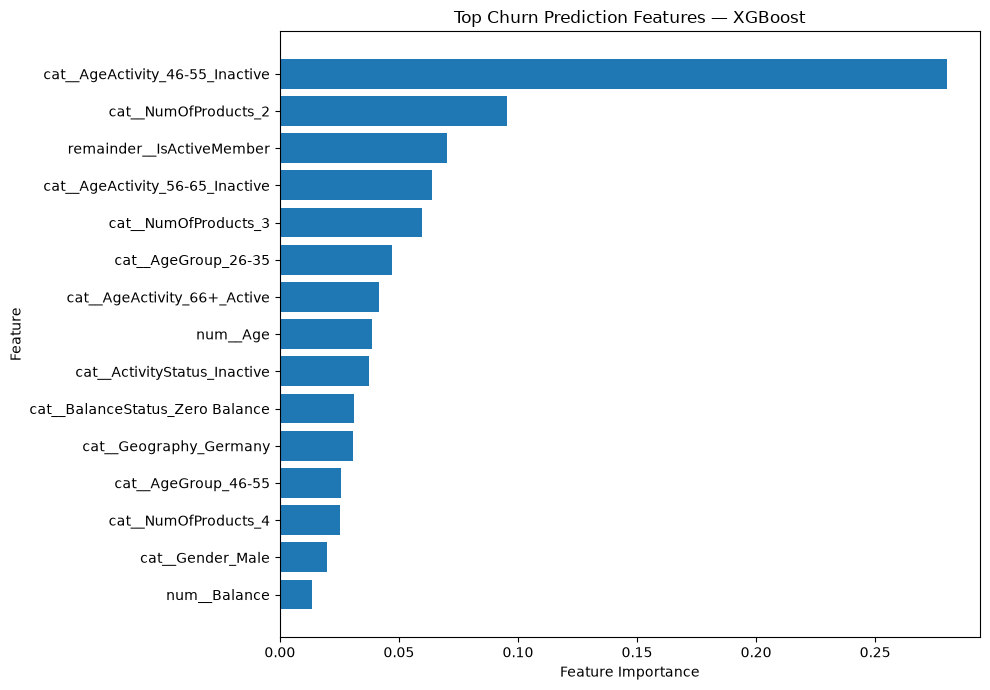

In [10]:
top_features = importance_df.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Churn Prediction Features — XGBoost")

plt.tight_layout()
plt.show()

In [11]:
importance_df["BusinessFeature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
)

In [12]:
importance_df[
    ["BusinessFeature", "Importance"]
].head(15)

,BusinessFeature,Importance
0,AgeActivity_46-55_Inactive,0.280027
1,NumOfProducts_2,0.095292
2,IsActiveMember,0.070019
3,AgeActivity_56-65_Inactive,0.063896
4,NumOfProducts_3,0.059831
5,AgeGroup_26-35,0.046988
6,AgeActivity_66+_Active,0.041555
7,Age,0.038779
8,ActivityStatus_Inactive,0.037238
9,BalanceStatus_Zero Balance,0.031219


In [13]:
def get_original_feature(feature_name):

    feature_name = (
        feature_name
        .replace("num__", "")
        .replace("cat__", "")
        .replace("remainder__", "")
    )

    categorical_features = [
        "Geography",
        "Gender",
        "NumOfProducts",
        "AgeGroup",
        "BalanceStatus",
        "ActivityStatus",
        "AgeActivity"
    ]

    for feature in categorical_features:
        if feature_name.startswith(feature + "_"):
            return feature

    return feature_name

In [14]:
importance_df["OriginalFeature"] = (
    importance_df["Feature"]
    .apply(get_original_feature)
)

In [15]:
grouped_importance = (
    importance_df
    .groupby("OriginalFeature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_importance

,OriginalFeature,Importance
0,AgeActivity,0.450793
1,NumOfProducts,0.180331
2,AgeGroup,0.087737
3,IsActiveMember,0.070019
4,Geography,0.040039
5,Age,0.038779
6,ActivityStatus,0.037238
7,BalanceStatus,0.031219
8,Gender,0.019661
9,Balance,0.013360


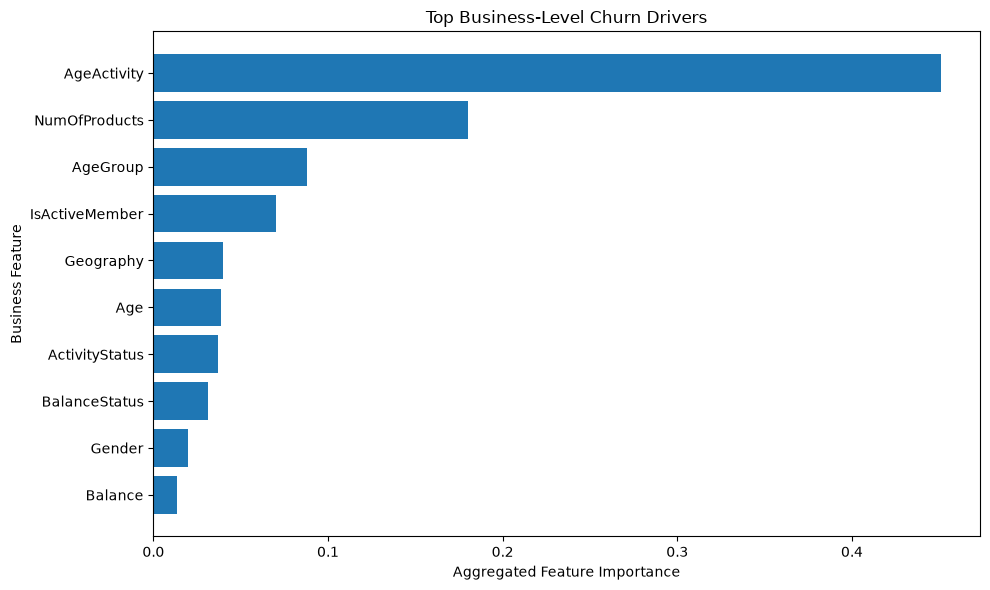

In [16]:
top_grouped = grouped_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_grouped["OriginalFeature"],
    top_grouped["Importance"]
)

plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Business Feature")
plt.title("Top Business-Level Churn Drivers")

plt.tight_layout()
plt.show()

In [17]:
explainer = shap.TreeExplainer(
    final_model
)

In [18]:
shap_values = explainer.shap_values(
    X_test_processed
)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (2000, 31)


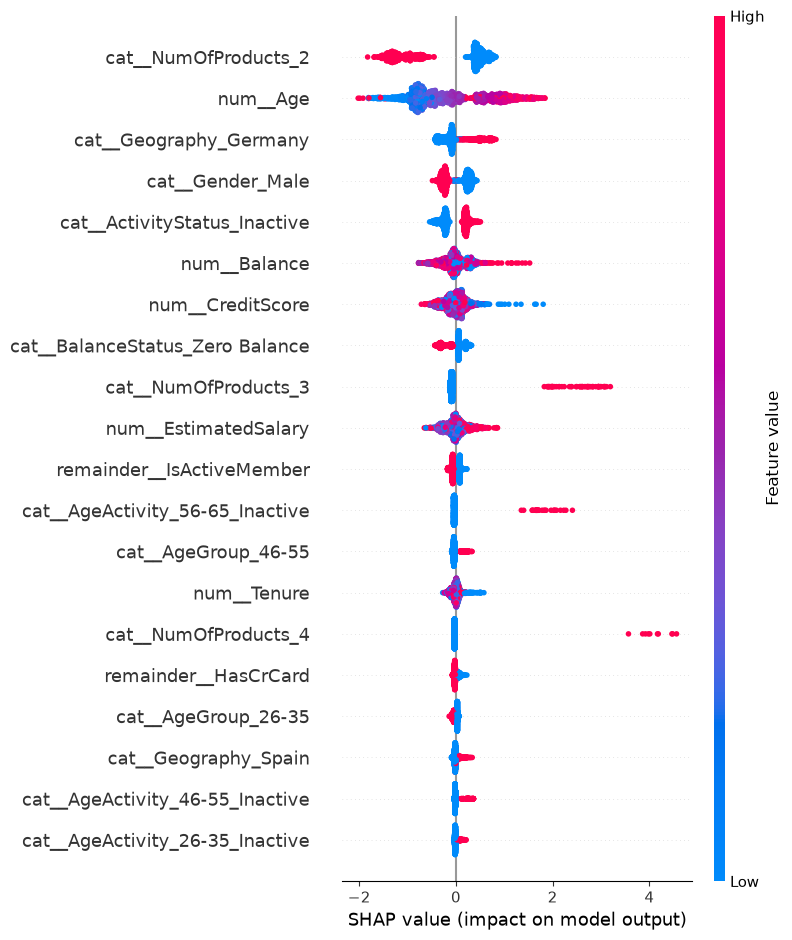

In [19]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=True
)

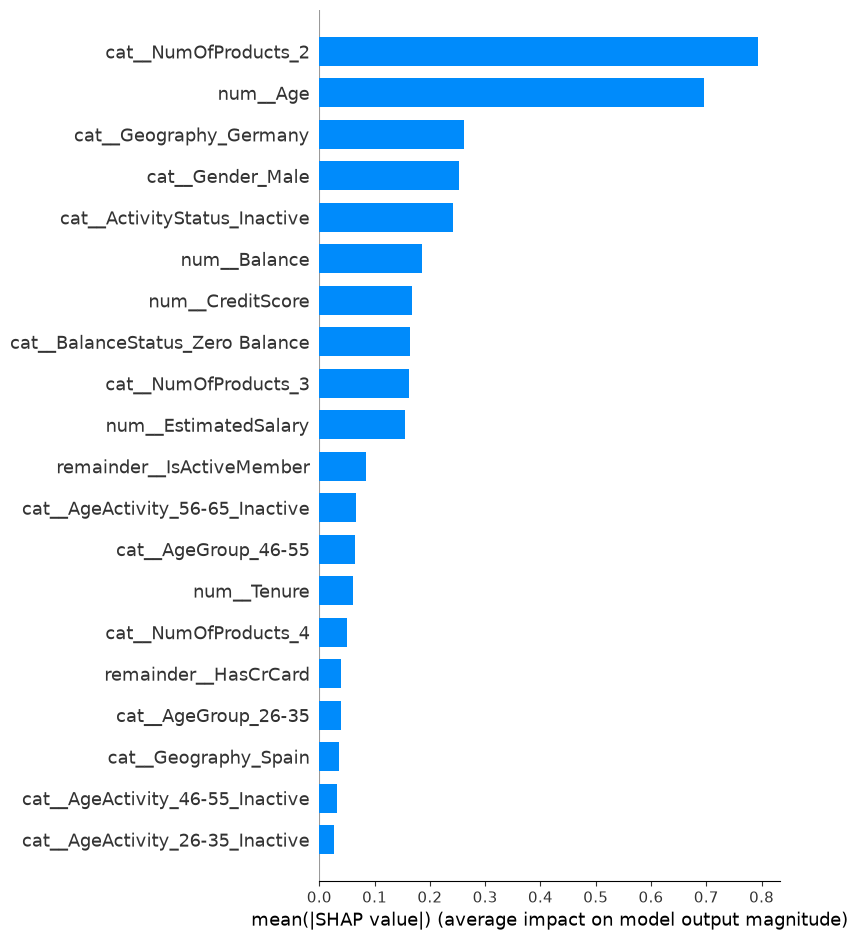

In [20]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

In [21]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP": mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "MeanAbsSHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.head(15)

,Feature,MeanAbsSHAP
0,cat__NumOfProducts_2,0.793590
1,num__Age,0.695757
2,cat__Geography_Germany,0.261915
3,cat__Gender_Male,0.252616
4,cat__ActivityStatus_Inactive,0.241939
5,num__Balance,0.186484
6,num__CreditScore,0.166803
7,cat__BalanceStatus_Zero Balance,0.164507
8,cat__NumOfProducts_3,0.161353
9,num__EstimatedSalary,0.155198


In [22]:
shap_importance["OriginalFeature"] = (
    shap_importance["Feature"]
    .apply(get_original_feature)
)

In [23]:
grouped_shap = (
    shap_importance
    .groupby("OriginalFeature")["MeanAbsSHAP"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_shap

,OriginalFeature,MeanAbsSHAP
0,NumOfProducts,1.004365
1,Age,0.695757
2,Geography,0.296693
3,Gender,0.252616
4,ActivityStatus,0.241939
5,AgeActivity,0.203658
6,Balance,0.186484
7,CreditScore,0.166803
8,BalanceStatus,0.164507
9,EstimatedSalary,0.155198


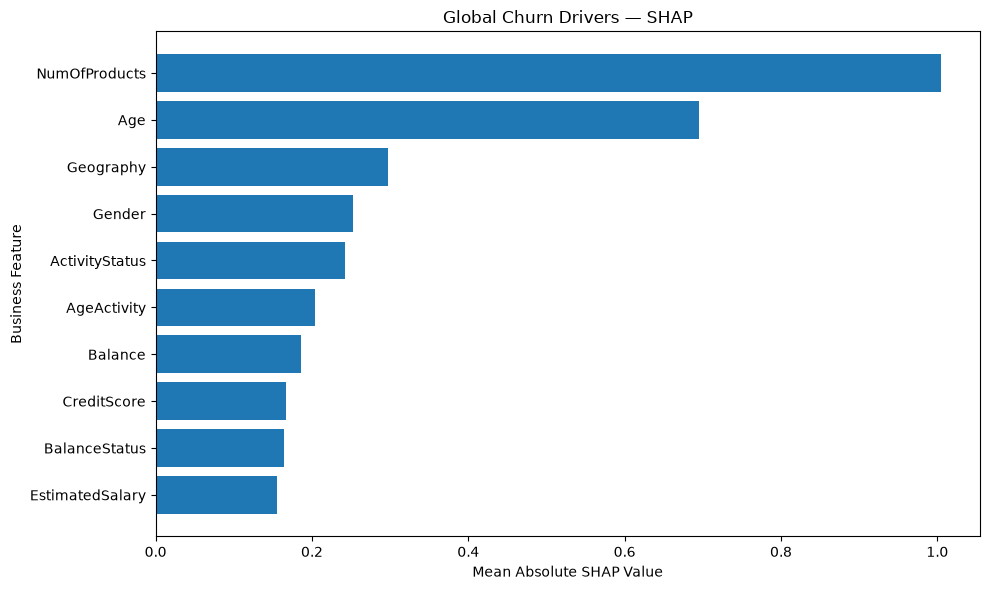

In [24]:
top_shap = grouped_shap.head(10).sort_values(
    "MeanAbsSHAP"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_shap["OriginalFeature"],
    top_shap["MeanAbsSHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Business Feature")
plt.title("Global Churn Drivers — SHAP")

plt.tight_layout()
plt.show()

In [25]:
importance_comparison = pd.merge(
    grouped_importance,
    grouped_shap,
    on="OriginalFeature",
    how="outer"
)

importance_comparison = (
    importance_comparison
    .sort_values(
        "MeanAbsSHAP",
        ascending=False
    )
)

importance_comparison

,OriginalFeature,Importance,MeanAbsSHAP
12,NumOfProducts,0.180331,1.004365
1,Age,0.038779,0.695757
9,Geography,0.040039,0.296693
8,Gender,0.019661,0.252616
0,ActivityStatus,0.037238,0.241939
2,AgeActivity,0.450793,0.203658
4,Balance,0.013360,0.186484
6,CreditScore,0.007989,0.166803
5,BalanceStatus,0.031219,0.164507
7,EstimatedSalary,0.008396,0.155198


In [33]:
# Generate predictions for all customers

X_all = df.drop(columns=["Exited"])

X_all_processed = preprocessor.transform(X_all)

churn_probability = final_model.predict_proba(
    X_all_processed
)[:, 1]

churn_prediction = (
    churn_probability >= 0.35
).astype(int)

# Create prediction dataset
customer_predictions = pd.DataFrame({
    "CustomerIndex": df.index,
    "ChurnProbability": churn_probability,
    "ChurnPrediction": churn_prediction
})

customer_predictions.head()

,CustomerIndex,ChurnProbability,ChurnPrediction
0,0,0.345453,0
1,1,0.190369,0
2,2,0.907523,1
3,3,0.041149,0
4,4,0.066439,0


In [36]:
customer_predictions["RiskLevel"] = pd.cut(
    customer_predictions["ChurnProbability"],
    bins=[-np.inf, 0.20, 0.35, 0.60, np.inf],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [37]:
print("=== RISK LEVEL DISTRIBUTION ===")

display(
    customer_predictions["RiskLevel"]
    .value_counts(sort=False)
    .to_frame("Customers")
)

=== RISK LEVEL DISTRIBUTION ===


,Customers
RiskLevel,
Low,6954
Moderate,1117
High,875
Very High,1054


In [38]:
customer_predictions["RiskLevel"].value_counts(
    sort=False
)

RiskLevel
Low          6954
Moderate     1117
High          875
Very High    1054
Name: count, dtype: int64

In [41]:
customer_predictions.head()

,CustomerIndex,ChurnProbability,ChurnPrediction,RiskLevel
0,0,0.345453,0,Moderate
1,1,0.190369,0,Low
2,2,0.907523,1,Very High
3,3,0.041149,0,Low
4,4,0.066439,0,Low


In [44]:
customer_risk = df.copy()

customer_risk["CustomerIndex"] = customer_risk.index

customer_risk = customer_risk.merge(
    customer_predictions,
    on="CustomerIndex",
    how="left"
)

print("Customer risk dataset shape:", customer_risk.shape)

customer_risk.head()

Customer risk dataset shape: (10000, 19)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceStatus,ActivityStatus,AgeActivity,CustomerIndex,ChurnProbability,ChurnPrediction,RiskLevel
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-45,Zero Balance,Active,36-45_Active,0,0.345453,0,Moderate
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-45,Positive Balance,Active,36-45_Active,1,0.190369,0,Low
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-45,Positive Balance,Inactive,36-45_Inactive,2,0.907523,1,Very High
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-45,Zero Balance,Inactive,36-45_Inactive,3,0.041149,0,Low
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-45,Positive Balance,Active,36-45_Active,4,0.066439,0,Low


In [47]:
highest_risk = (
    customer_risk
    .sort_values(
        "ChurnProbability",
        ascending=False
    )
    .head(20)
)

display(
    highest_risk[
        [
            "CustomerIndex",
            "Geography",
            "Age",
            "Balance",
            "NumOfProducts",
            "IsActiveMember",
            "ChurnProbability",
            "RiskLevel"
        ]
    ]
)

,CustomerIndex,Geography,Age,Balance,NumOfProducts,IsActiveMember,ChurnProbability,RiskLevel
2614,2614,Germany,58,106458.31,4,0,0.999219,Very High
70,70,Germany,58,133745.44,4,0,0.998964,Very High
8923,8923,Germany,55,118772.71,4,0,0.998685,Very High
7715,7715,France,62,43772.66,3,0,0.998259,Very High
2154,2154,Germany,65,126306.64,3,0,0.997997,Very High
5950,5950,Germany,57,112281.60,3,0,0.997980,Very High
9438,9438,Germany,63,120916.52,3,0,0.997715,Very High
4013,4013,Germany,57,162082.31,4,0,0.997297,Very High
1993,1993,Germany,60,134250.17,3,0,0.997291,Very High
1962,1962,Spain,52,143542.36,3,0,0.997119,Very High


In [48]:
customer_risk_path = (
    REPORTS_PATH /
    "customer_churn_predictions.csv"
)

customer_risk.to_csv(
    customer_risk_path,
    index=False
)

print(
    "Customer predictions saved to:",
    customer_risk_path
)

Customer predictions saved to: C:\Users\balle\customer-churn-prediction-retention-analytics\reports\customer_churn_predictions.csv


In [49]:
importance_df.to_csv(
    REPORTS_PATH /
    "xgboost_feature_importance.csv",
    index=False
)

grouped_importance.to_csv(
    REPORTS_PATH /
    "business_feature_importance.csv",
    index=False
)

shap_importance.to_csv(
    REPORTS_PATH /
    "shap_feature_importance.csv",
    index=False
)

importance_comparison.to_csv(
    REPORTS_PATH /
    "feature_importance_comparison.csv",
    index=False
)

print("Explainability reports saved.")

Explainability reports saved.


## Model Explainability Findings

The final XGBoost model was analyzed using both model-based feature
importance and SHAP-based feature importance.

At the encoded feature level, the AgeActivity interaction was the
strongest XGBoost feature, particularly the 46–55 inactive segment.
When encoded features were aggregated to their original business
variables, AgeActivity and NumOfProducts were the most influential
groups.

SHAP analysis provided a complementary perspective. NumOfProducts and
Age were the two features with the highest mean absolute SHAP values,
followed by Geography, Gender, ActivityStatus, and AgeActivity.

The agreement between multiple importance methods indicates that age,
product configuration, geography, and customer activity are important
components of the model's churn predictions.

However, Age, AgeGroup, and AgeActivity are derived from overlapping
information. Therefore, their importance should not be interpreted as
independent causal effects or added together as separate causes of churn.

The model identifies 1,929 of the 10,000 customers as High or Very High
risk under the project's reporting bands. These customers will be
further analyzed in the retention prioritization stage.

Feature importance describes how the model uses variables to make
predictions and should not be interpreted as proof that a variable
causes customer churn.

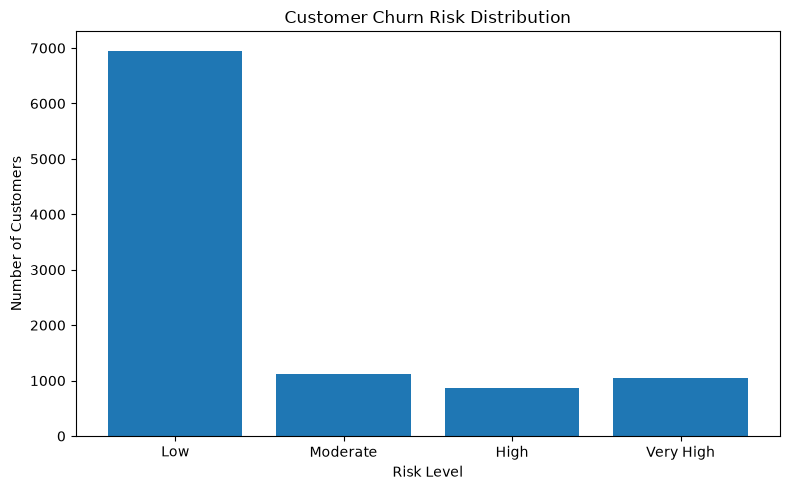

In [54]:
risk_counts = (
    customer_risk["RiskLevel"]
    .value_counts(sort=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    risk_counts.index.astype(str),
    risk_counts.values
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Risk Distribution")

plt.tight_layout()
plt.show()

In [55]:
customer_risk.to_csv(
    REPORTS_PATH / "customer_churn_predictions.csv",
    index=False
)

print("Customer churn predictions saved.")

Customer churn predictions saved.


In [56]:
files_to_check = [
    "customer_churn_predictions.csv",
    "xgboost_feature_importance.csv",
    "business_feature_importance.csv",
    "shap_feature_importance.csv",
    "feature_importance_comparison.csv"
]

for file in files_to_check:
    print(
        file,
        "→",
        (REPORTS_PATH / file).exists()
    )

customer_churn_predictions.csv → True
xgboost_feature_importance.csv → True
business_feature_importance.csv → True
shap_feature_importance.csv → True
feature_importance_comparison.csv → True
